In [29]:
import numpy as np
import matplotlib.pyplot as plt
print('Setup complete!')

Setup complete!


In [30]:
dt = 0.001
T = 1.0
time = np.arange(0, T, dt)

V_rest   = -70.0
V_thresh = -55.0
V_reset  = -75.0
tau      = 0.020
C        = 1.0

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV



Knowledge Check 1

1. V_reset is lower than V_rest to model afterhyperpolarization - the brief dip below resting potential after a real neuron fires. Potassium channels open after an action potential, pushing the membrane below rest. This creates a refractory period that prevents immediate re-firing and makes the model biologically realistic.

2. Tau controls how quickly the membrane potential leaks back toward rest when there is no input. A small tau means the neuron forgets input quickly and needs strong current to fire. A larger tau means the neuron integrates input over a longer window, making it more sensitive to weak but sustained signals.


In [31]:
I_input = np.zeros(len(time))
I_input[200:800] = 800.0

V = np.zeros(len(time))
V[0] = V_rest
spikes = []

for t in range(len(time) - 1):
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)
    V[t+1] = V[t] + dV
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 10 spikes


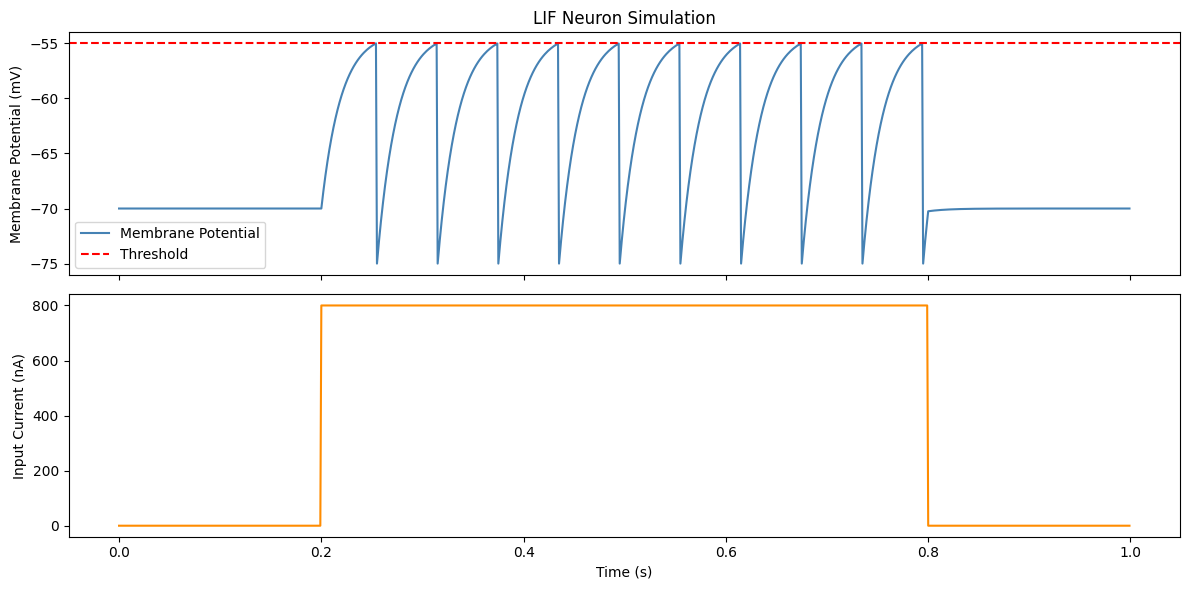

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time, V, color='steelblue', label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

ax2.plot(time, I_input, color='darkorange')
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()


Knowledge Check 2

1. V curves upward between spikes rather than rising straight. As V rises above rest, the leak term -(V - V_rest)/tau grows and partially opposes the input current, slowing the rate of rise. This produces the characteristic exponential approach to a steady-state value.

2. After current turns off at t=0.8s, V decays exponentially back to V_rest (-70 mV). With no input, the only active term is the leak, which always pulls V toward rest. The neuron returns to rest within about 60-80 ms.


Reflection 1

The simulation captures realistic features: voltage integrating toward threshold, a post-spike reset below rest, and exponential decay between spikes - all matching the passive membrane dynamics of real neurons.

What looks oversimplified: real action potentials shoot up to +40 mV and back down via Na+ and K+ channels. Here the spike is invisible - just a threshold crossing and instant reset. The model also has no spike-frequency adaptation, no dendritic computation, and no stochastic noise.


In [33]:
def rate_encode(values, num_steps=100):
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))
    for t in range(num_steps):
        random_vals = np.random.rand(num_neurons)
        spikes[t] = (random_vals < values).astype(float)
    return spikes

test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 23 spikes in 200 steps
Value 0.3 -> 58 spikes in 200 steps
Value 0.5 -> 101 spikes in 200 steps
Value 0.7 -> 142 spikes in 200 steps
Value 0.9 -> 182 spikes in 200 steps


In [34]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))
    for i in range(num_neurons):
        if values[i] > threshold:
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1
    return spikes


Knowledge Check 3

1. Rate coding loses the exact timing of individual spikes - only the overall firing rate is preserved. Signal strength is represented by how many spikes occur per second, not when each one happens.

2. Temporal coding allows faster decisions because a downstream neuron can respond to the very first spike it receives. High-value signals spike at time step 0 or 1, so a decision is possible almost instantly. Rate coding requires waiting and counting spikes over a time window - inherently slower.

3. Sound localization is a real-world example where timing matters more than frequency. The brain determines the direction of a sound by measuring the arrival time difference between the two ears, sometimes as small as 10-20 microseconds. The timing of the first spike from each ear carries all the useful information.

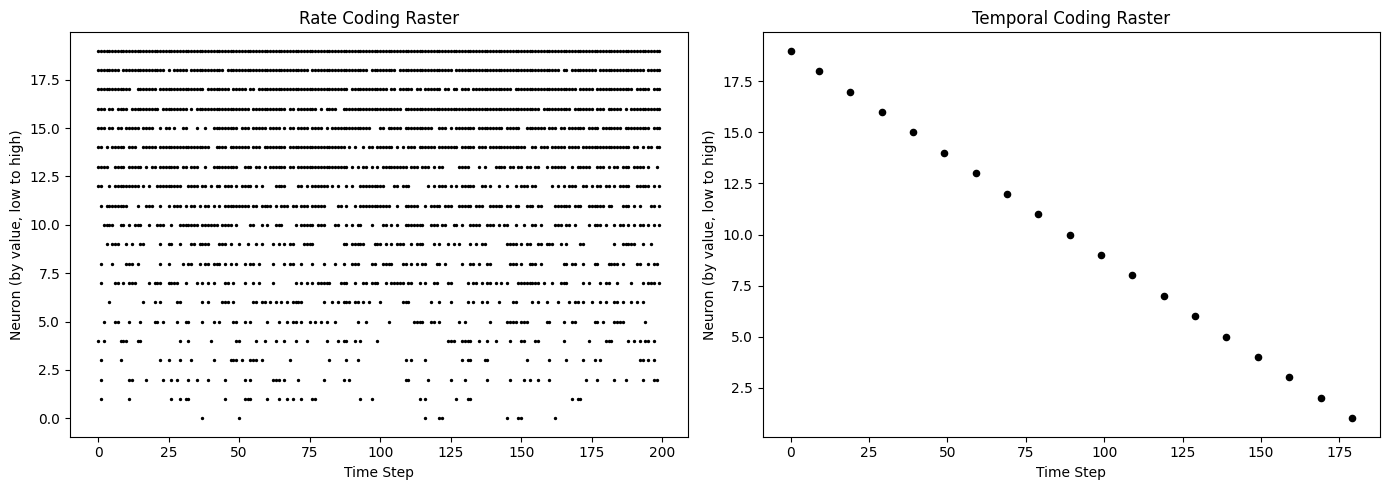

In [35]:
signal = np.linspace(0.05, 1.0, 20)
rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

times_r, neurons_r = np.where(rate_spikes == 1)
ax1.scatter(times_r, neurons_r, s=2, color='black')
ax1.set_title('Rate Coding Raster')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value, low to high)')

times_t, neurons_t = np.where(temp_spikes == 1)
ax2.scatter(times_t, neurons_t, s=20, color='black')
ax2.set_title('Temporal Coding Raster')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Neuron (by value, low to high)')

plt.tight_layout()
plt.show()


Reflection 2

The rate coding raster shows scattered dots throughout the full time window, denser at the top (high-value neurons) and sparse at the bottom. The temporal coding raster shows a clean diagonal line - high-value neurons spike early (left), low-value spike late (right).

Temporal coding is better for speed since information is available at the first spike. Rate coding is better for noise-resistant precision since averaging many spikes reduces randomness. The brain uses both because different circuits have different needs - reflexes and sound localization require temporal precision, while slower perceptual decisions benefit from the noise averaging rate coding provides.


In [36]:
N = 5
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

weights = np.zeros((N, N))
weights[0, 2] = 4000.0
weights[1, 3] = 4000.0
weights[2, 4] = 4000.0
weights[3, 4] = 4000.0

I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 800.0
I_ext[150:350, 1] = 800.0

V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]
syn_current = np.zeros(N)

for t in range(steps - 1):
    just_spiked = np.zeros(N)
    for n in range(N):
        if t > 0 and V_net[t, n] == V_reset:
            just_spiked[n] = 1.0

    syn_current = 0.99 * syn_current + weights.T @ just_spiked

    for n in range(N):
        I_total = I_ext[t, n] + syn_current[n]
        dV = dt * (-(V_net[t, n] - V_rest) / tau + I_total / C)
        V_net[t+1, n] = V_net[t, n] + dV
        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset

for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 5 spikes
Neuron 1: 3 spikes
Neuron 2: 74 spikes
Neuron 3: 46 spikes
Neuron 4: 313 spikes


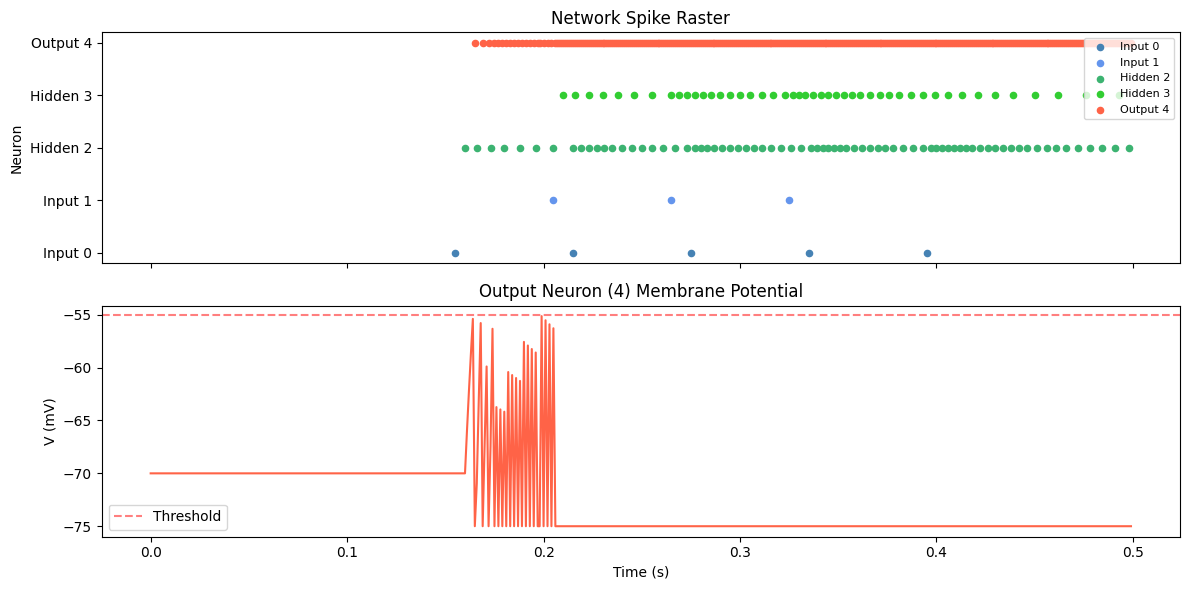

In [37]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

colors = ['steelblue', 'cornflowerblue', 'mediumseagreen', 'limegreen', 'tomato']
labels = ['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4']

for n in range(N):
    if spike_log[n]:
        ax1.scatter(spike_log[n], [n]*len(spike_log[n]),
                    s=20, color=colors[n], label=labels[n])

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(labels)
ax1.legend(loc='upper right', fontsize=8)

ax2.plot(time_net, V_net[:, 4], color='tomato')
ax2.axhline(y=V_thresh, color='r', linestyle='--', alpha=0.5, label='Threshold')
ax2.legend()
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()


Knowledge Check 4

1. No - the output neuron fires less frequently than the input neurons. Input neurons are driven by strong direct current. Hidden neurons only fire when they receive enough synaptic pulses from inputs. The output neuron depends on convergent pulses from both hidden neurons arriving close in time, which naturally reduces its firing rate across layers.

2. Weights control how much current one neuron delivers to another per spike. Doubling the weights would make downstream neurons fire more easily and more often. Halving them could reduce or eliminate firing in later layers if each spike no longer delivers enough charge to reach threshold.

3. Making weights[3, 4] negative means neuron 3 would subtract current from the output neuron each time it fires instead of adding to it. This could reduce or silence the output neuron - neuron 3 would act as an inhibitory gate opposing neuron 2's excitation. This kind of excitation/inhibition balance is fundamental to how real neural circuits control gain and selectivity.

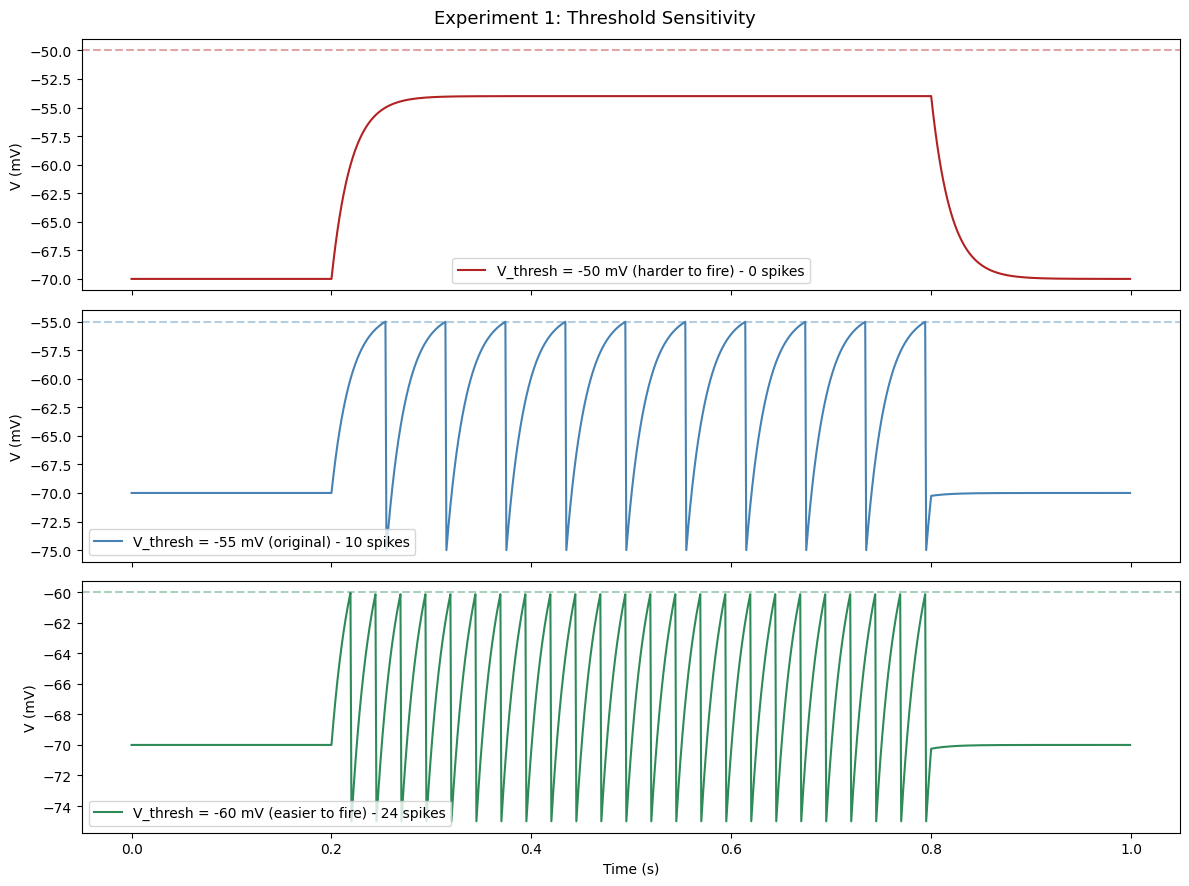

In [38]:
I_exp = np.zeros(len(time))
I_exp[200:800] = 800.0

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, thresh, label, color in zip(
    axes,
    [-50.0, -55.0, -60.0],
    ['V_thresh = -50 mV (harder to fire)', 'V_thresh = -55 mV (original)', 'V_thresh = -60 mV (easier to fire)'],
    ['firebrick', 'steelblue', 'seagreen']
):
    V_e = np.zeros(len(time)); V_e[0] = V_rest; sp = []
    for t in range(len(time)-1):
        dV = dt*(-(V_e[t]-V_rest)/tau + I_exp[t]/C)
        V_e[t+1] = V_e[t]+dV
        if V_e[t+1] >= thresh:
            sp.append(time[t+1]); V_e[t+1] = V_reset
    ax.plot(time, V_e, color=color, label=f'{label} - {len(sp)} spikes')
    ax.axhline(y=thresh, color=color, linestyle='--', alpha=0.4)
    ax.set_ylabel('V (mV)'); ax.legend()

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Experiment 1: Threshold Sensitivity', fontsize=13)
plt.tight_layout(); plt.show()


Experiment 1: Threshold Sensitivity
Parameter changed: V_thresh from -55 to -50 mV (harder) and -60 mV (easier)
Expected: Higher threshold = fewer spikes, lower threshold = more spikes
What happened: With -50 mV the neuron fired fewer times with longer intervals. With -60 mV it fired much more frequently with shorter intervals.
Why it makes sense: The LIF drives V toward a fixed steady-state (~-54 mV). If threshold is above that, the neuron barely reaches it. If below, it crosses quickly after each reset.

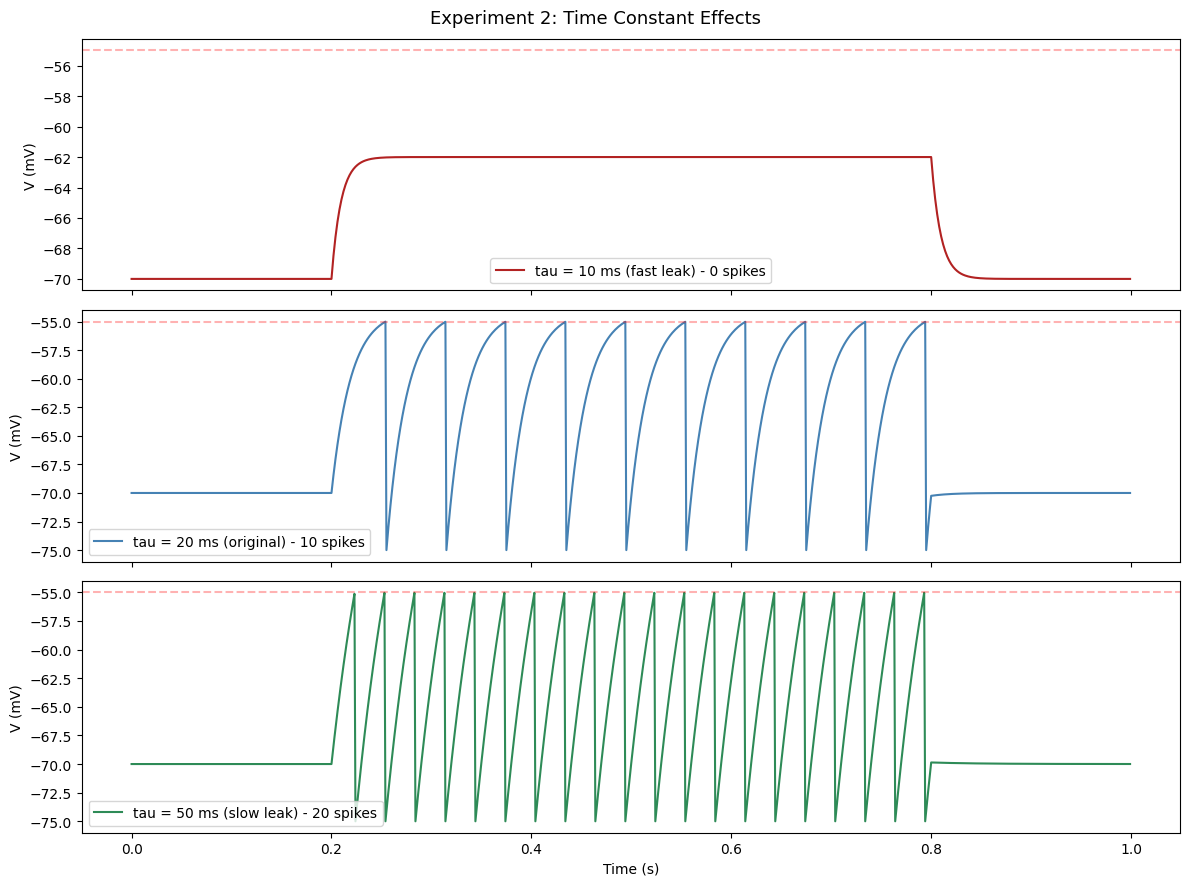

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, tau_val, label, color in zip(
    axes,
    [0.010, 0.020, 0.050],
    ['tau = 10 ms (fast leak)', 'tau = 20 ms (original)', 'tau = 50 ms (slow leak)'],
    ['firebrick', 'steelblue', 'seagreen']
):
    V_e = np.zeros(len(time)); V_e[0] = V_rest; sp = []
    for t in range(len(time)-1):
        dV = dt*(-(V_e[t]-V_rest)/tau_val + I_exp[t]/C)
        V_e[t+1] = V_e[t]+dV
        if V_e[t+1] >= -55.0:
            sp.append(time[t+1]); V_e[t+1] = V_reset
    ax.plot(time, V_e, color=color, label=f'{label} - {len(sp)} spikes')
    ax.axhline(y=-55, color='r', linestyle='--', alpha=0.3)
    ax.set_ylabel('V (mV)'); ax.legend()

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Experiment 2: Time Constant Effects', fontsize=13)
plt.tight_layout(); plt.show()


Experiment 2: Time Constant Effects
Parameter changed: tau from 20 ms to 10 ms and 50 ms
Expected: Different integration windows and curve shapes between spikes
What happened: tau = 10 ms produced faster steeper rises. tau = 50 ms produced more gradual curved rises and higher firing rate.
Why it makes sense: V_ss = V_rest + I*tau/C. Larger tau raises the steady-state making the neuron more sensitive. Biologically, fast-spiking interneurons have tau ~5-10 ms while pyramidal neurons have tau ~20-30 ms.

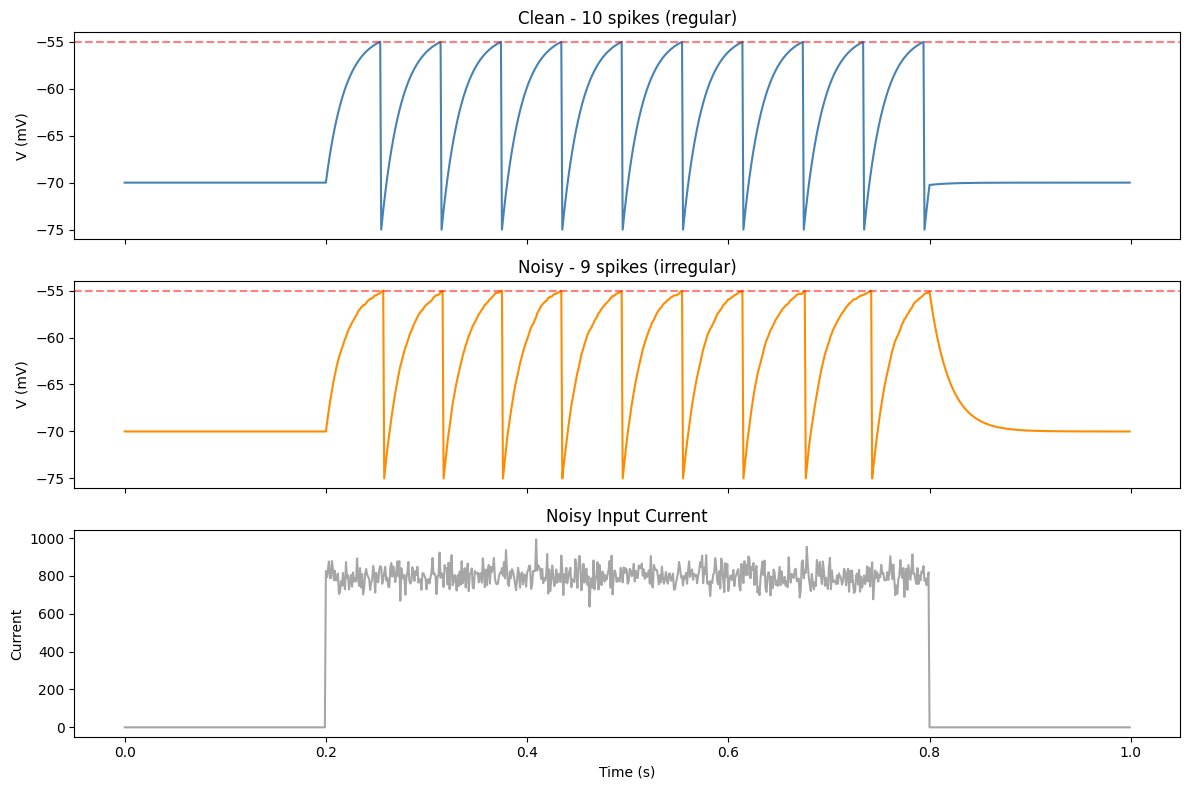

In [40]:
np.random.seed(42)
I_noisy = np.zeros(len(time))
I_noisy[200:800] = 800.0 + np.random.randn(600) * 50.0

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

V_c = np.zeros(len(time)); V_c[0] = V_rest; sp_c = []
for t in range(len(time)-1):
    dV = dt*(-(V_c[t]-V_rest)/tau + I_exp[t]/C)
    V_c[t+1] = V_c[t]+dV
    if V_c[t+1] >= V_thresh:
        sp_c.append(t); V_c[t+1] = V_reset

V_n = np.zeros(len(time)); V_n[0] = V_rest; sp_n = []
for t in range(len(time)-1):
    dV = dt*(-(V_n[t]-V_rest)/tau + I_noisy[t]/C)
    V_n[t+1] = V_n[t]+dV
    if V_n[t+1] >= V_thresh:
        sp_n.append(t); V_n[t+1] = V_reset

ax1.plot(time, V_c, color='steelblue')
ax1.axhline(y=V_thresh, color='r', linestyle='--', alpha=0.5)
ax1.set_ylabel('V (mV)'); ax1.set_title(f'Clean - {len(sp_c)} spikes (regular)')

ax2.plot(time, V_n, color='darkorange')
ax2.axhline(y=V_thresh, color='r', linestyle='--', alpha=0.5)
ax2.set_ylabel('V (mV)'); ax2.set_title(f'Noisy - {len(sp_n)} spikes (irregular)')

ax3.plot(time, I_noisy, color='gray', alpha=0.7)
ax3.set_ylabel('Current'); ax3.set_xlabel('Time (s)')
ax3.set_title('Noisy Input Current')

plt.tight_layout(); plt.show()


Experiment 3: Noisy Input
Parameter changed: Replaced constant current with current + Gaussian noise (sigma = 50)
Expected: Irregular spike timing compared to the regular clean pattern
What happened: Clean input produced evenly spaced spikes. Noisy input produced irregular intervals - some spikes came early when noise pushed current high, some late when it pulled current down.
Why it makes sense: Noise directly perturbs dV each step so V rises faster or slower unpredictably. This is more realistic - real neurons receive thousands of stochastic synaptic inputs, making their spike trains naturally irregular.




Final Reflection

Reflection 3 - Time constant and firing behavior:
Tau controls the neuron's temporal integration window. A short tau makes it forget input quickly - it needs strong fast bursts to fire. A long tau lets it accumulate input over a wider window, making it sensitive to weak sustained signals. Biologically, tau = Rm x Cm reflects passive membrane properties. Fast-spiking interneurons have tau ~5-10 ms; pyramidal neurons have tau ~20-30 ms. These differences tune each cell type to a specific computational role in its circuit.

Reflection 4 - Rate vs temporal coding:
Temporal coding preserved more information per spike - one spike at a specific time uniquely encodes a value with no ambiguity. Rate coding is noisier and requires time averaging. However rate coding is more robust to timing jitter. The brain uses both because the auditory system needs microsecond temporal precision for sound localization, while the visual system uses rate coding to robustly signal luminance.

Reflection 5 - Spike propagation through the network:
Spikes flowed in a clear hierarchy: input neurons fired first, hidden neurons next, output neuron last and least frequently. Firing rate decreased across layers because synaptic pulses are brief and the output neuron only reaches threshold when enough arrive close in time. This mirrors real cortical circuits where information flows through hierarchical layers. Unlike our model, real circuits also have feedback connections and lateral inhibition.

Reflection 6 - What LIF captures vs misses:
LIF captures well: integrate-and-fire dynamics, passive membrane leak, refractory behavior, and the f-I relationship. It misses: spike shape (real action potentials reach +40 mV - LIF produces no spike shape), dendritic computation across complex branching trees, spike-frequency adaptation due to slow K+ channels, and neurotransmitter kinetics (AMPA/NMDA/GABA dynamics).

Reflection 7 - What surprised me:
The most surprising thing was how much information a single precisely-timed spike can carry. In temporal coding, one spike encodes the same information that rate coding needs dozens of spikes over hundreds of milliseconds to convey. Biological brains are asynchronous, event-driven, and sparse - most neurons are silent most of the time. If we develop better training methods for spiking networks, we could get AI systems far more energy-efficient than today's - the brain runs on ~20 watts while modern AI training runs on megawatts.